In [12]:
# Cell 1: Imports and Setup
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

# Enable seaborn for professional plots
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'  # Journal-friendly font
plt.rcParams['font.serif'] = ['Times New Roman']


regions = ['US-CAL-CISO', 'CA-ON', 'DE', 'AU-QLD']  # List of regions
base_dirs = ['/home/chad/Desktop/multi-tier-llm-routing-v2/results/US-CAL-CISO_2024_qor_sweep', 
            '/home/chad/Desktop/multi-tier-llm-routing-v2/results/CA-ON_2024_qor_sweep', 
            '/home/chad/Desktop/multi-tier-llm-routing-v2/results/DE_2024_qor_sweep', 
            '/home/chad/Desktop/multi-tier-llm-routing-v2/results/AU-QLD_2024_qor_sweep'
            ]
# Generate qor values from 0.10 to 0.99 in 0.01 steps
qor_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]

# Machine types and total hours
machine_types = ['0', '1', '2']
total_hours = 8760

# Nested dictionary to hold results: {region: {qor: results_dict}}
all_results = {}

In [13]:
# Cell 2: Data Processing Loop (Extended for Multi-Region)
for region, base_dir in zip(regions, base_dirs):
    results = {}  # Local dict per region
    for qor in qor_values:
        dir_name = f'qor_{qor:.2f}'
        file_path = os.path.join(base_dir, dir_name, 'checkpoint_hour_8760.json')
        
        if not os.path.exists(file_path):
            print(f"Skipping {region} {dir_name}: File not found at {file_path}")
            continue
        
        # Load the JSON data from file
        with open(file_path, 'r') as file:
            data = json.load(file)
        
        # Extract the deployments list
        deployments = data['deployments']
        
        # Initialize dictionaries for calculations
        total_active_counts = {key: 0 for key in machine_types}
        active_hours_count = {key: 0 for key in machine_types}
        
        # Process each deployment entry
        for deployment in deployments:
            machines_per_type = deployment['machines_per_type']
            for typ in machine_types:
                count = machines_per_type[typ]
                total_active_counts[typ] += count
                if count > 0:
                    active_hours_count[typ] += 1
        
        # Additional: Total machine-hours across all types
        total_all_machines = sum(total_active_counts.values())
        
        # Calculations
        time_based_utilization_pct = {}
        average_active_machines = {}
        overall_utilization_pct = {}
        for typ in machine_types:
            time_based_utilization_pct[typ] = (active_hours_count[typ] / total_hours) * 100
            average_active_machines[typ] = total_active_counts[typ] / total_hours
            overall_utilization_pct[typ] = (total_active_counts[typ] / total_all_machines) * 100 if total_all_machines > 0 else 0.0
        
        # Store results
        results[qor] = {
            'time_based': time_based_utilization_pct,
            'avg_active': average_active_machines,
            'overall': overall_utilization_pct
        }
    
    all_results[region] = results

print("Data loading complete for regions:", list(all_results.keys()))

Data loading complete for regions: ['US-CAL-CISO', 'CA-ON', 'DE', 'AU-QLD']


In [14]:
# Cell 3: Create Unified DataFrame with Regions
# Collect data for DataFrame
data_rows = []
for region in regions:
    if region not in all_results:
        print(f"Warning: No data for region {region}")
        continue
    for qor in sorted(all_results[region].keys()):
        for typ in machine_types:
            data_rows.append({
                'Region': region,
                'QOR': qor,
                'Type': typ,
                'Time-Based Utilization (%)': round(all_results[region][qor]['time_based'][typ], 2),
                'Average Active Machines': round(all_results[region][qor]['avg_active'][typ], 2),
                'Overall Utilization (%)': round(all_results[region][qor]['overall'][typ], 2)
            })

# Create unified DataFrame
region_df = pd.DataFrame(data_rows)

# Display a sample
print("Unified Regional QOR Sweep Results (First 10 rows):")
display(region_df.head(10))

Unified Regional QOR Sweep Results (First 10 rows):


,Region,QOR,Type,Time-Based Utilization (%),Average Active Machines,Overall Utilization (%)
0,US-CAL-CISO,0.1,0,99.49,2.00,16.60
1,US-CAL-CISO,0.1,1,99.63,8.65,71.78
2,US-CAL-CISO,0.1,2,73.92,1.40,11.62
3,US-CAL-CISO,0.2,0,67.92,1.11,9.54
4,US-CAL-CISO,0.2,1,99.58,7.80,67.40
5,US-CAL-CISO,0.2,2,94.05,2.67,23.06
6,US-CAL-CISO,0.3,0,56.44,1.03,9.07
7,US-CAL-CISO,0.3,1,99.17,7.06,62.35
8,US-CAL-CISO,0.3,2,97.48,3.23,28.58
9,US-CAL-CISO,0.4,0,63.65,1.12,9.83


In [15]:
# Cell 4: Pivoted Table for Structured View
# Create pivoted DataFrame with Region/QOR as multi-index and metrics/types as columns
pivot_df = region_df.pivot(index=['Region', 'QOR'], columns=['Type'])

print("Pivoted Regional Results (Condensed View):")
display(pivot_df.head(20))  # Adjust as needed

Pivoted Regional Results (Condensed View):


Time-Based Utilization (%)               Average Active Machines  \
Type                                 0      1      2                       0   
Region QOR                                                                     
AU-QLD 0.10                      99.47  99.69  73.65                    1.99   
       0.20                      57.88  99.68  95.80                    0.88   
       0.30                      43.88  99.67  98.14                    0.76   
       0.40                      55.68  99.67  98.80                    0.95   
       0.50                      64.20  99.66  99.16                    0.97   
       0.60                      68.56  99.60  99.33                    1.07   
       0.70                      67.82  99.54  99.46                    1.16   
       0.80                      63.71  99.52  99.52                    1.11   
       0.90                      60.95  95.33  99.55                    1.10   
       0.99                      73.15  85.56  99.59                    1.52   
CA-ON  0.10                      99.38  97.56  88.08                    2.06   
       0.20                      71.88  97.40  93.69                    1.32   
       0.30                      59.16  94.42  96.72                    1.13   
       0.40                      66.83  94.08  97.76                    1.21   
       0.50                      72.96  92.27  98.31                    1.21   
       0.60                      75.84  90.95  98.50                    1.31   
       0.70                      73.97  91.19  98.93                    1.38   
       0.80                      65.80  88.79  99.12                    1.33   
       0.90                      73.32  84.59  99.25                    1.56   
       0.99                      78.56  88.11  99.34                    1.67   

                        Overall Utilization (%)                
Type            1     2                       0      1      2  
Region QOR                                                     
AU-QLD 0.10  9.25  1.29                   15.88  73.82  10.30  
       0.20  8.53  2.55                    7.34  71.35  21.32  
       0.30  7.91  2.98                    6.56  67.86  25.58  
       0.40  7.15  3.61                    8.11  61.04  30.85  
       0.50  6.49  4.30                    8.29  55.15  36.56  
       0.60  5.78  4.98                    9.09  48.84  42.07  
       0.70  5.18  5.57                    9.76  43.50  46.74  
       0.80  4.59  6.21                    9.35  38.52  52.14  
       0.90  3.75  7.03                    9.26  31.55  59.18  
       0.99  2.36  8.17                   12.60  19.56  67.84  
CA-ON  0.10  5.23  3.28                   19.53  49.49  30.99  
       0.20  4.69  4.22                   12.92  45.84  41.24  
       0.30  4.16  4.77                   11.22  41.35  47.43  
       0.40  3.97  5.10                   11.82  38.57  49.61  
       0.50  3.59  5.63                   11.57  34.46  53.96  
       0.60  3.29  6.06                   12.26  30.90  56.84  
       0.70  3.10  6.42                   12.64  28.48  58.88  
       0.80  2.88  6.85                   12.02  26.03  61.95  
       0.90  2.53  7.30                   13.71  22.18  64.11  
       0.99  2.39  7.88                   14.01  20.04  65.94

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

Plot 1 saved as 'regional_stacked_utilization.pdf'


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

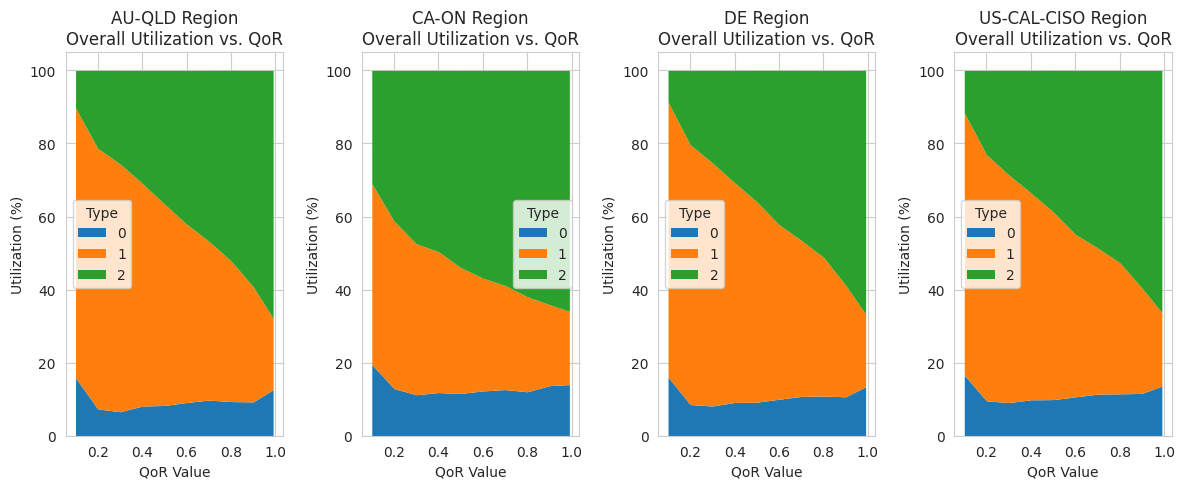

In [16]:
# Cell 5: Plot 1 - Stacked Area Plot (Cumulative Utilization Across Regions)
# Aggregate to total time-based utilization per region-QOR (example metric)
agg_df = region_df.groupby(['Region', 'QOR', 'Type'])['Overall Utilization (%)'].sum().reset_index()
pivot_agg_df = agg_df.pivot_table(values='Overall Utilization (%)', index=['Region', 'QOR'], columns='Type', fill_value=0)

fig, axes = plt.subplots(1, len(regions), figsize=(12, 5))
for idx, region in enumerate(pivot_agg_df.index.get_level_values(0).unique()):
    region_df_slice = pivot_agg_df.loc[region]
    region_df_slice.plot.area(ax=axes[idx], title=f'{region} Region\nOverall Utilization vs. QoR', 
                              xlabel='QoR Value', ylabel='Utilization (%)', linewidth=0)

plt.tight_layout()
plt.savefig('regional_stacked_utilization.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("Plot 1 saved as 'regional_stacked_utilization.pdf'")
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

Plot 2 saved as 'facet_qor_regions.pdf'


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

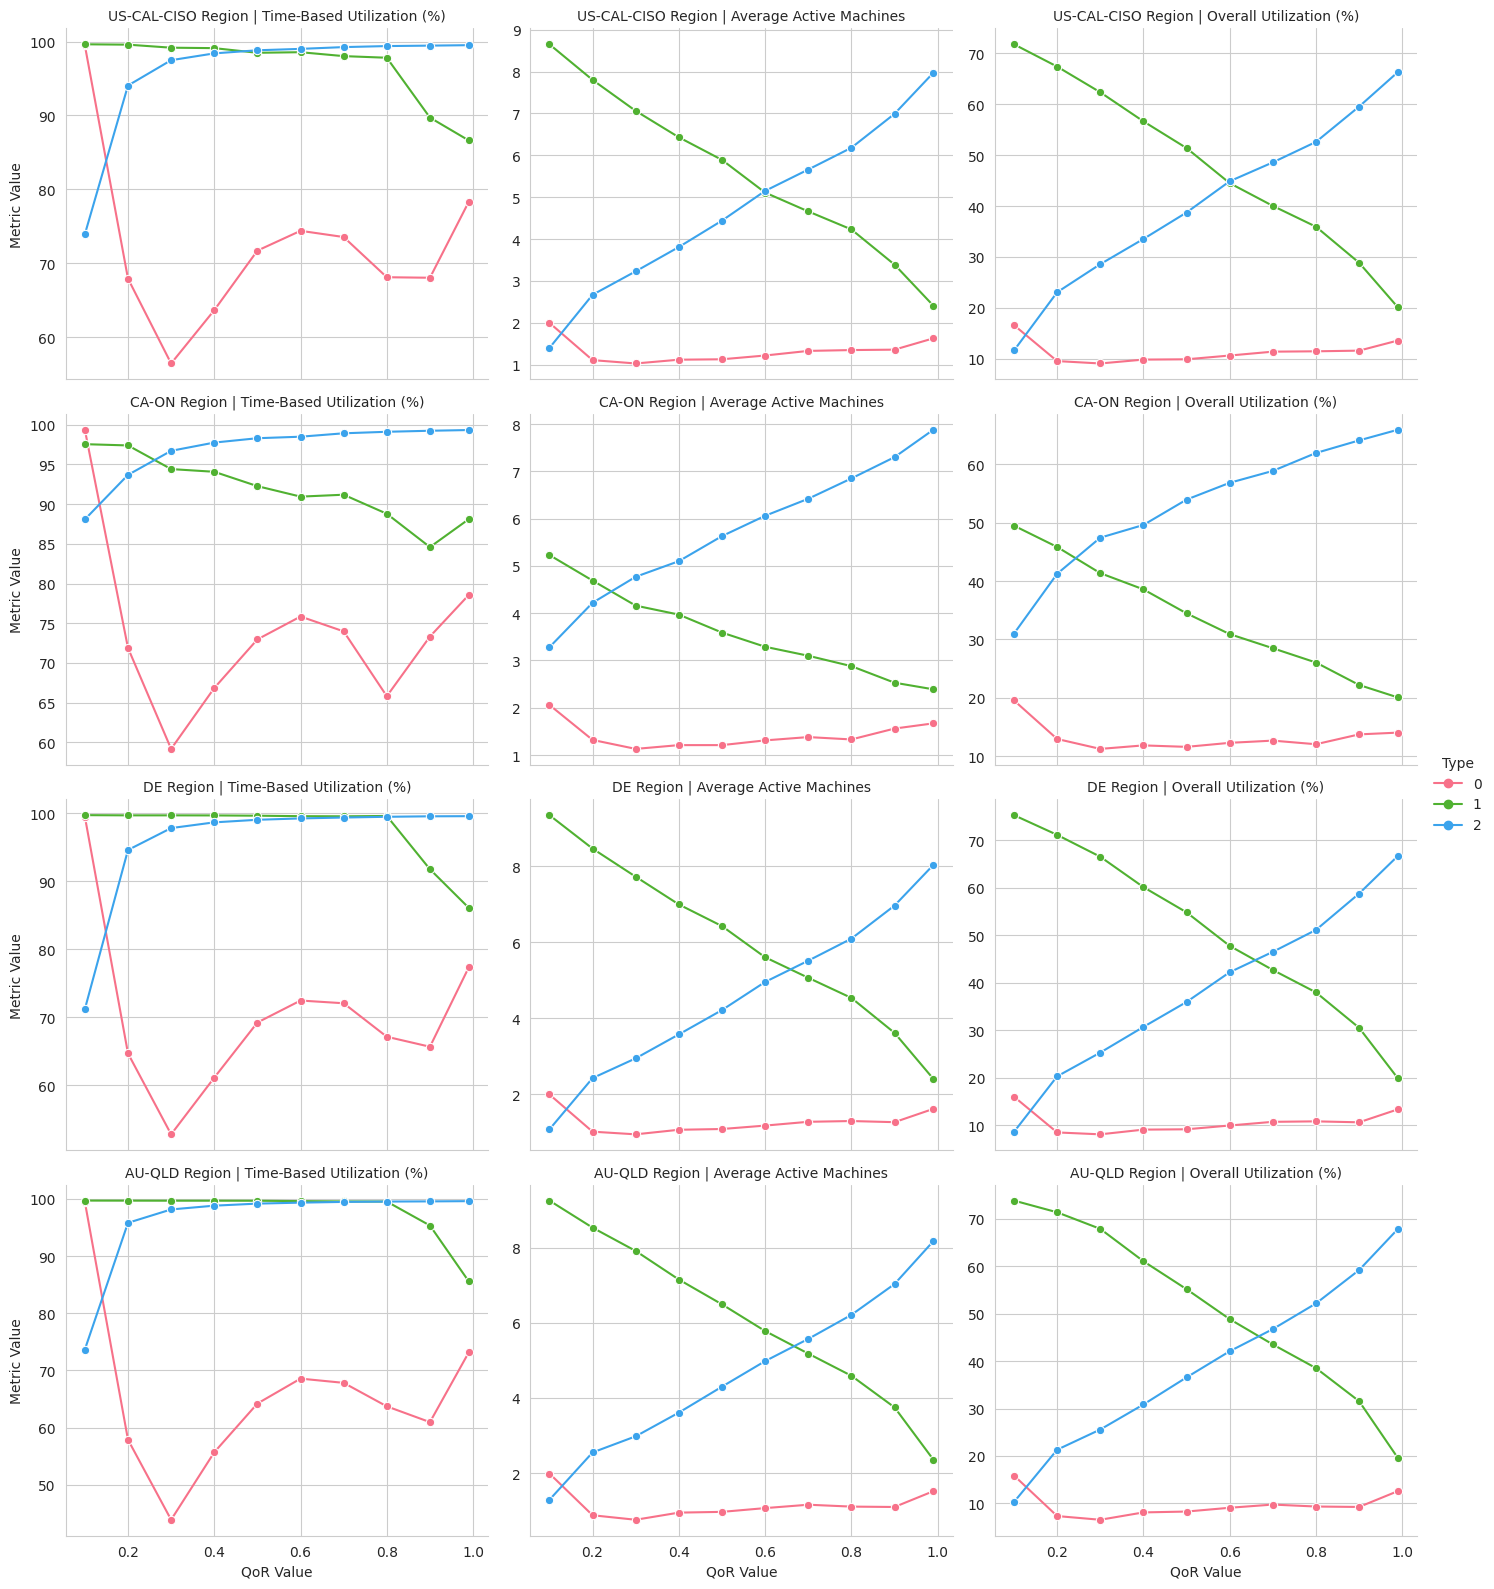

In [17]:
# Cell 6: Plot 2 - Facet Grid Line Plots (QoR Trends Facetted by Region and Metric)
melted_region_df = region_df.melt(id_vars=['Region', 'QOR', 'Type'], 
                                  value_vars=['Time-Based Utilization (%)', 'Average Active Machines', 'Overall Utilization (%)'], 
                                  var_name='Metric', value_name='Value')

g = sns.relplot(data=melted_region_df, x='QOR', y='Value', hue='Type', col='Metric', row='Region', 
                kind='line', marker='o', palette='husl', height=4, aspect=1.2, facet_kws={'sharey': False})
g.set_axis_labels('QoR Value', 'Metric Value')
g.set_titles(row_template='{row_name} Region', col_template='{col_name}')
plt.savefig('facet_qor_regions.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("Plot 2 saved as 'facet_qor_regions.pdf'")
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

Plot 3 saved as 'radar_qor_regions.pdf'


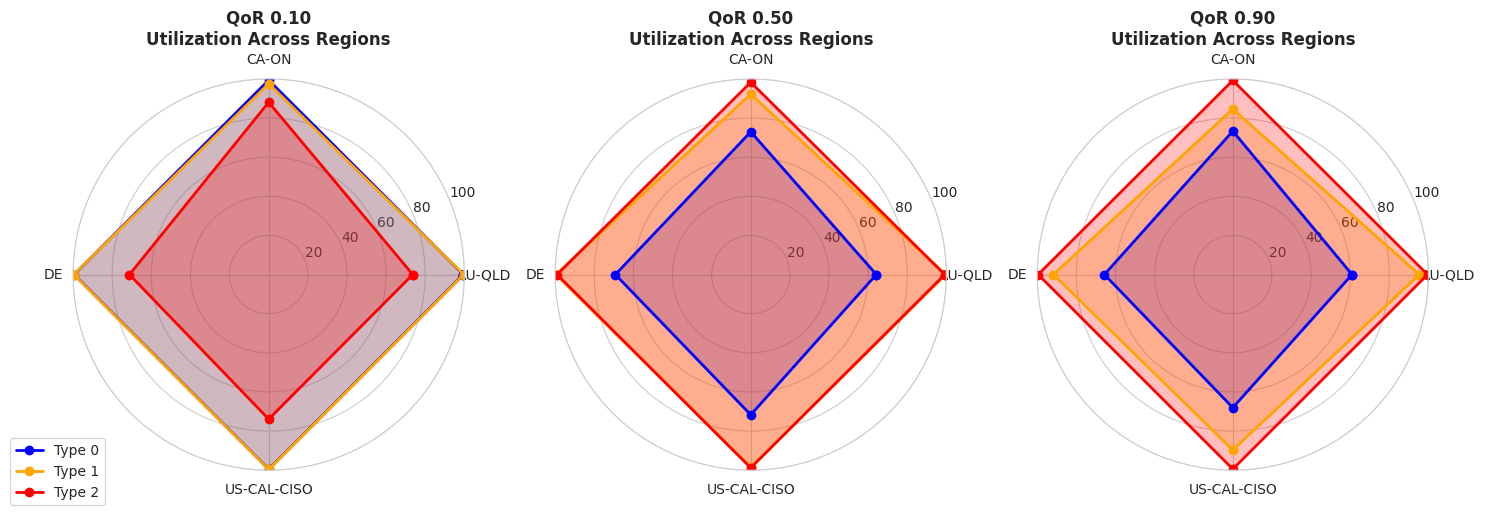

In [18]:
# Cell 7: Plot 3 - Radar/Spider Plot (Multidimensional Comparison at Select QoR Levels)
select_qors = [0.10, 0.50, 0.90]  # Selectively compare at low, mid, high QoR
colors = ['blue', 'orange', 'red']  # One per machine type
fig, axes = plt.subplots(1, len(select_qors), figsize=(15, 5), subplot_kw={'projection': 'polar'})

for idx, qor in enumerate(select_qors):
    ax = axes[idx]
    qor_data = region_df[region_df['QOR'] == qor].groupby(['Region', 'Type'])['Time-Based Utilization (%)'].mean().unstack(fill_value=0)
    
    if qor_data.empty:
        print(f"No data for QoR {qor}")
        continue
    
    angles = [n / float(len(qor_data.index)) * 2 * pi for n in range(len(qor_data.index))]
    angles += angles[:1]  # Close the loop
    
    for i, typ in enumerate(machine_types):
        values = qor_data[typ].values.tolist()
        if values:
            values += values[:1]  # Close loop
            ax.plot(angles, values, 'o-', linewidth=2, label=f'Type {typ}', color=colors[i])
            ax.fill(angles, values, alpha=0.25, color=colors[i])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(qor_data.index, fontsize=10)
    ax.set_title(f'QoR {qor:.2f}\nUtilization Across Regions', size=12, fontweight='bold')
    ax.set_rlim(0, 100)  # Assuming 0-100% scale
    if idx == 0:
        ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

plt.tight_layout()
plt.savefig('radar_qor_regions.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("Plot 3 saved as 'radar_qor_regions.pdf'")
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

Plot 3 saved as 'radar_qor_regions.pdf' (using Overall Utilization %)


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

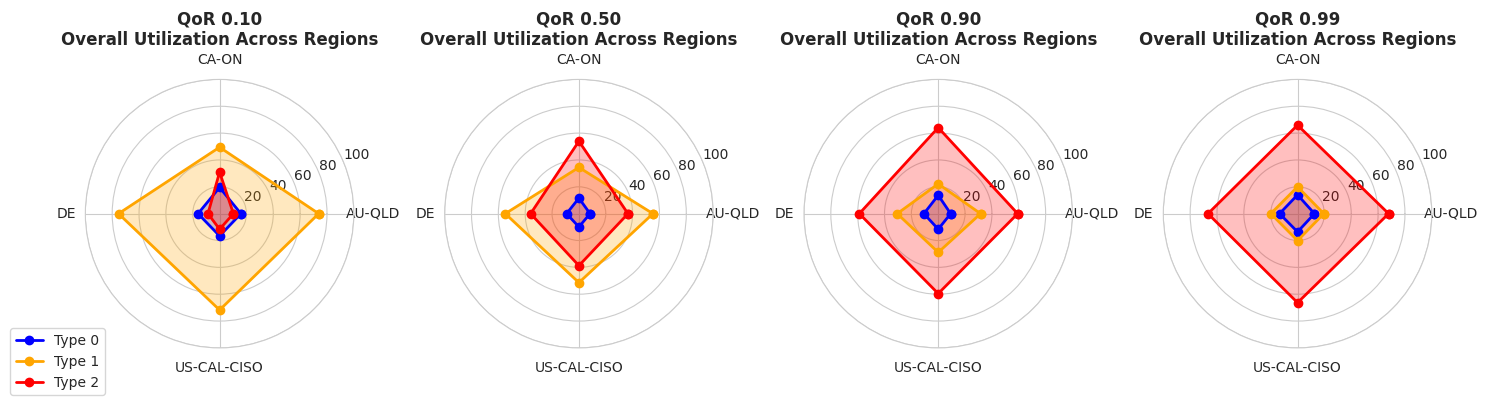

In [19]:
# Cell 7: Plot 3 - Radar/Spider Plot (Multidimensional Comparison at Select QoR Levels)
# Updated to use 'Overall Utilization (%)' (share of total machine-hours across machine types)
select_qors = [0.10, 0.50, 0.90,0.99]  # Selectively compare at low, mid, high QoR
colors = ['blue', 'orange', 'red']  # One per machine type
fig, axes = plt.subplots(1, len(select_qors), figsize=(15, 5), subplot_kw={'projection': 'polar'})

for idx, qor in enumerate(select_qors):
    ax = axes[idx]
    # Changed column name from 'Time-Based Utilization (%)' to 'Overall Utilization (%)'
    qor_data = region_df[region_df['QOR'] == qor].groupby(['Region', 'Type'])['Overall Utilization (%)'].mean().unstack(fill_value=0)
    
    if qor_data.empty:
        print(f"No data for QoR {qor}")
        continue
    
    angles = [n / float(len(qor_data.index)) * 2 * pi for n in range(len(qor_data.index))]
    angles += angles[:1]  # Close the loop
    
    for i, typ in enumerate(machine_types):
        values = qor_data[typ].values.tolist()
        if values:
            values += values[:1]  # Close loop
            ax.plot(angles, values, 'o-', linewidth=2, label=f'Type {typ}', color=colors[i])
            ax.fill(angles, values, alpha=0.25, color=colors[i])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(qor_data.index, fontsize=10)
    ax.set_title(f'QoR {qor:.2f}\nOverall Utilization Across Regions', size=12, fontweight='bold')
    ax.set_rlim(0, 100)  # Assuming 0-100% scale
    if idx == 0:
        ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

plt.tight_layout()
plt.savefig('radar_qor_regions.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("Plot 3 saved as 'radar_qor_regions.pdf' (using Overall Utilization %)")
plt.show()